Upload your corpus file:


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving corpus_small_clean.txt to corpus_small_clean (1).txt
Upload your generated poems file:


Saving generated_poems.txt to generated_poems (1).txt

Corpus size    : 1,034,622 chars
Generated size : 800,097 chars

            CORPUS             |           GENERATED           
---------------------------------------------------------------
thy                     894   | sea                     996
thou                    625   | love                    908
love                    554   | sun                     820
one                     477   | light                   707
like                    465   | day                     675
thee                    432   | night                   516
yet                     393   | like                    512
shall                   378   | world                   470
man                     358   | thy                     438
may                     350   | wind                    418
life                    332   | thou                    417
day                     321   | long                    413
light                   298   | 

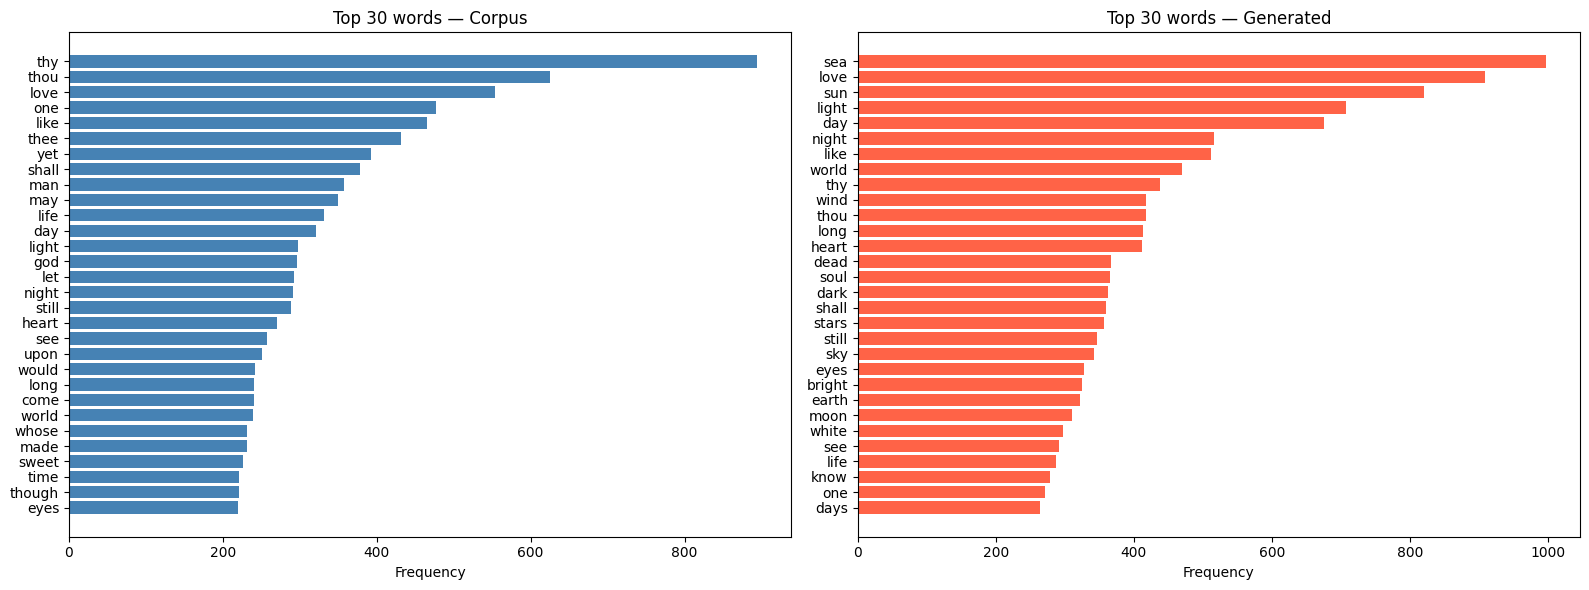

✓ Plot saved as word_frequency_comparison.png


In [ ]:
from collections import Counter
import re
import nltk
import matplotlib.pyplot as plt
from google.colab import files

nltk.download('stopwords')
from nltk.corpus import stopwords

# ── Load files ────────────────────────────────────────────────────────────────
print("Upload your corpus file:")
uploaded = files.upload()
corpus_text = open(list(uploaded.keys())[0], "r").read()

print("Upload your generated poems file:")
uploaded = files.upload()
generated_text = open(list(uploaded.keys())[0], "r").read()

print(f"\nCorpus size    : {len(corpus_text):,} chars")
print(f"Generated size : {len(generated_text):,} chars")

# ── Stopwords ─────────────────────────────────────────────────────────────────
STOPWORDS = set(stopwords.words('english'))  # ← change to 'french', 'spanish', etc.

# ── Frequency function ────────────────────────────────────────────────────────
def get_word_freq(text, n=30):
    words = re.findall(r'\b\w+\b', text.lower())
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return Counter(words).most_common(n)

corpus_freq    = get_word_freq(corpus_text)
generated_freq = get_word_freq(generated_text)

# ── Print side by side ────────────────────────────────────────────────────────
print(f"\n{'CORPUS':^30} | {'GENERATED':^30}")
print("-" * 63)
for (cw, cc), (gw, gc) in zip(corpus_freq, generated_freq):
    print(f"{cw:<20} {cc:>6}   | {gw:<20} {gc:>6}")

# ── Vocabulary overlap ────────────────────────────────────────────────────────
corpus_top    = {w for w, _ in corpus_freq}
generated_top = {w for w, _ in generated_freq}
overlap       = corpus_top & generated_top
print(f"\nVocabulary overlap (top 30): {len(overlap)}/30 words")
print(f"Shared words: {sorted(overlap)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_c, counts_c = zip(*corpus_freq)
words_g, counts_g = zip(*generated_freq)

axes[0].barh(words_c[::-1], counts_c[::-1], color="steelblue")
axes[0].set_title("Top 30 words — Corpus")
axes[0].set_xlabel("Frequency")

axes[1].barh(words_g[::-1], counts_g[::-1], color="tomato")
axes[1].set_title("Top 30 words — Generated")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("word_frequency_comparison.png", dpi=150)
plt.show()
print("✓ Plot saved as word_frequency_comparison.png")

Corpus lines    : 26424
Generated lines : 15497

── Corpus ──────────────────────
  Mean   : 38.0 chars
  Median : 39.0 chars
  Std    : 12.3 chars
  Min    : 1  Max: 338

── Generated ──────────────────────
  Mean   : 50.5 chars
  Median : 46.0 chars
  Std    : 25.9 chars
  Min    : 1  Max: 646


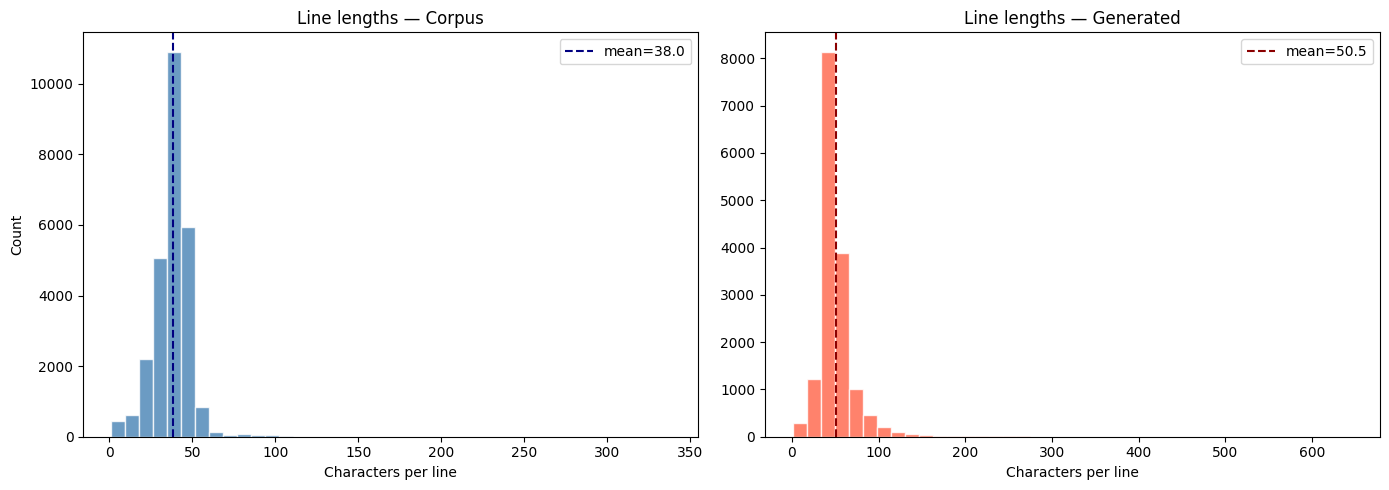


── Corpus ──────────────────────────────────
  Adjacent rhymes  (AABB): 12.2%  (3110/25541 pairs)
  Alternating rhymes (ABAB): 9.8%  (2504/25540 pairs)

── Generated ──────────────────────────────────
  Adjacent rhymes  (AABB): 3.8%  (581/15276 pairs)
  Alternating rhymes (ABAB): 3.0%  (453/15275 pairs)

── Most common line endings ──────────────────────────
         CORPUS           |         GENERATED        
-----------------------------------------------------
  -ght            636       |   -ght            685
  -ing            462       |   -sea            523
  -ain            392       |   -day            268
  -ore            302       |   -ing            257
  -ine            287       |   -ove            246
  -one            265       |   -sun            240
  -ear            262       |   -ain            238
  -ace            261       |   -one            213
  -and            245       |   -air            204
  -ind            236       |   -ore            184
  -all    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── Helper: split text into non-empty lines ───────────────────────────────────
def get_lines(text):
    return [l for l in text.split("\n") if l.strip()]

corpus_lines    = get_lines(corpus_text)
generated_lines = get_lines(generated_text)

print(f"Corpus lines    : {len(corpus_lines)}")
print(f"Generated lines : {len(generated_lines)}")

# ══════════════════════════════════════════════════════════════════════════════
# 1. LINE LENGTH COMPARISON
# ══════════════════════════════════════════════════════════════════════════════

def line_length_stats(lines, label):
    lengths = [len(l) for l in lines]
    print(f"\n── {label} ──────────────────────")
    print(f"  Mean   : {np.mean(lengths):.1f} chars")
    print(f"  Median : {np.median(lengths):.1f} chars")
    print(f"  Std    : {np.std(lengths):.1f} chars")
    print(f"  Min    : {min(lengths)}  Max: {max(lengths)}")
    return lengths

corpus_lengths    = line_length_stats(corpus_lines,    "Corpus")
generated_lengths = line_length_stats(generated_lines, "Generated")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(corpus_lengths,    bins=40, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(np.mean(corpus_lengths),    color="navy", linestyle="--", label=f"mean={np.mean(corpus_lengths):.1f}")
axes[0].set_title("Line lengths — Corpus")
axes[0].set_xlabel("Characters per line")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(generated_lengths, bins=40, color="tomato",    alpha=0.8, edgecolor="white")
axes[1].axvline(np.mean(generated_lengths), color="darkred", linestyle="--", label=f"mean={np.mean(generated_lengths):.1f}")
axes[1].set_title("Line lengths — Generated")
axes[1].set_xlabel("Characters per line")
axes[1].legend()

plt.tight_layout()
plt.savefig("line_lengths.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. RHYME DETECTION & DENSITY
# ══════════════════════════════════════════════════════════════════════════════

def get_ending(line, n_chars=3):
    """Extract the last n characters of the last word of a line."""
    words = line.strip().split()
    if not words:
        return None
    last_word = re.sub(r'[^a-zA-Z]', '', words[-1]).lower()  # strip punctuation
    if len(last_word) < 2:
        return None
    return last_word[-n_chars:]

def rhyme_density(lines, n_chars=3):
    """
    Compute % of adjacent line pairs that rhyme,
    i.e. share the same last n characters.
    """
    endings = [get_ending(l, n_chars) for l in lines]
    endings = [e for e in endings if e is not None]

    pairs        = 0
    rhyming      = 0
    for i in range(len(endings) - 1):
        pairs += 1
        if endings[i] == endings[i+1]:
            rhyming += 1

    density = rhyming / pairs * 100 if pairs > 0 else 0
    return density, rhyming, pairs

# Also look at alternating lines (ABAB pattern: lines i and i+2)
def rhyme_density_alternating(lines, n_chars=3):
    endings = [get_ending(l, n_chars) for l in lines]
    endings = [e for e in endings if e is not None]

    pairs   = 0
    rhyming = 0
    for i in range(len(endings) - 2):
        pairs += 1
        if endings[i] == endings[i+2]:
            rhyming += 1

    density = rhyming / pairs * 100 if pairs > 0 else 0
    return density, rhyming, pairs

# ── Run on both texts ─────────────────────────────────────────────────────────
for label, lines in [("Corpus", corpus_lines), ("Generated", generated_lines)]:
    d_adj, r_adj, p_adj   = rhyme_density(lines)
    d_alt, r_alt, p_alt   = rhyme_density_alternating(lines)
    print(f"\n── {label} ──────────────────────────────────")
    print(f"  Adjacent rhymes  (AABB): {d_adj:.1f}%  ({r_adj}/{p_adj} pairs)")
    print(f"  Alternating rhymes (ABAB): {d_alt:.1f}%  ({r_alt}/{p_alt} pairs)")

# ── Most common endings ───────────────────────────────────────────────────────
def top_endings(lines, n=15, n_chars=3):
    endings = [get_ending(l, n_chars) for l in lines if get_ending(l, n_chars)]
    return Counter(endings).most_common(n)

print("\n── Most common line endings ──────────────────────────")
print(f"{'CORPUS':^25} | {'GENERATED':^25}")
print("-" * 53)
for (ce, cc), (ge, gc) in zip(top_endings(corpus_lines), top_endings(generated_lines)):
    print(f"  -{ce:<10}  {cc:>6}       |   -{ge:<10}  {gc:>6}")